# Multiple Linear Regression — Google Colab

**Goal:** Predict a continuous target from **multiple** features using Multiple Linear Regression.

| Example | Features (X) | Target (y) | Dataset |
|---------|--------------|------------|---------|
| **Example 1** | R&D Spend, Administration, Marketing Spend, State | Profit | `../Datasets/50_Startups.csv` |
| **Example 2** | Area_sqft, Bedrooms, Age_years | Price | `../Datasets/house_price.csv` |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Install & Imports |
| Phase 1 | Data Pre-processing | Load → Cleaning → Encoding → Split |
| Phase 2 | Algorithm | Train → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)


## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, numpy, and seaborn quietly.


In [1]:
# Install required libraries quietly (-q hides output)
!pip install -q scikit-learn pandas matplotlib numpy seaborn



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for data handling, preprocessing, modeling, and evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, seaborn, and sklearn modules.


In [2]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots
import seaborn as sns           # Statistical visualizations (optional styling)

from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.impute import SimpleImputer              # Fill missing values
from sklearn.preprocessing import OneHotEncoder         # Encode categorical columns
from sklearn.compose import ColumnTransformer         # Apply transforms to columns
from sklearn.linear_model import LinearRegression     # Multiple Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
sns.set_theme(style='whitegrid')            # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible splits

print('Libraries ready')                      # Confirm all imports loaded successfully


Libraries ready


---
# Example 1: Startup Profit — Multiple Linear Regression

Predict **Profit** from three spending columns and the **State** where the startup operates.

| Column | Role | Description |
|--------|------|-------------|
| `R&D Spend` | Feature (X₁) | Research & development budget |
| `Administration` | Feature (X₂) | Administrative expenses |
| `Marketing Spend` | Feature (X₃) | Marketing budget |
| `State` | Feature (X₄) | US state (categorical → One-Hot) |
| `Profit` | Target (y) | Annual profit in USD |

**File:** `../Datasets/50_Startups.csv`


---
# Phase 1: Data Pre-processing

Prepare the data before training the model — same template is reused for other algorithms.


## Example 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/50_Startups.csv` and displays basic statistics.


In [3]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/50_Startups.csv')  # Read CSV into a DataFrame

FEATURE_COLS = ['R&D Spend', 'Administration', 'Marketing Spend', 'State']  # Independent variables
TARGET_COL = 'Profit'  # Dependent variable to predict

print('First 5 rows:')          # Print a label for the table below
display(dataset.head())         # Show the first 5 rows to inspect the data

print('\nDataset info:')       # Print a label for column types and null counts
dataset.info()                  # Show column names, data types, and non-null counts

print('\nStatistical summary:')  # Print a label for numeric statistics
display(dataset.describe())       # Show count, mean, std, min, max, quartiles

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')  # Total rows and columns


First 5 rows:


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB

Statistical summary:


,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000



Shape: 50 rows x 5 columns


## Example 1 — Cell 2: Data Cleaning (Handling Missing Values)

Data cleaning includes checking missing values, removing duplicates, and using SimpleImputer when needed.

**What this cell does:** Checks for nulls, drops duplicate rows, and imputes missing numeric values.


In [4]:
# Step 2) Data cleaning

print('Missing values per column:')  # Print a label
print(dataset.isnull().sum())        # Count NaN values in each column

rows_before = len(dataset)                              # Store row count before cleaning
dataset = dataset.drop_duplicates().reset_index(drop=True)  # Remove duplicates and reset row index
rows_after = len(dataset)                               # Store row count after cleaning
print(f'\nDuplicates removed: {rows_before - rows_after}')  # Show how many duplicates were removed

numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()  # List numeric columns only
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')  # Replace NaN with column mean
if dataset.isnull().sum().sum() > 0:               # If any missing values exist
    dataset[numeric_cols] = imputer.fit_transform(dataset[numeric_cols])  # Impute numeric columns only
    print('Missing values imputed with mean')      # Confirm imputation was applied
else:
    print('No missing values — imputer not applied')  # Skip imputation when data is complete

print(f'\nRows after cleaning: {rows_after}')    # Final number of rows in the dataset


Missing values per column:
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Duplicates removed: 0
No missing values — imputer not applied

Rows after cleaning: 50


## Example 1 — Cell 3: Categorical Data Encoding

ML algorithms require numeric input. The `State` column is categorical and will be One-Hot Encoded.

**What this cell does:** One-Hot encodes `State` and builds the feature matrix X with all numeric columns.


In [5]:
# Step 3) Categorical encoding for Multiple Linear Regression

cat_cols = [col for col in FEATURE_COLS if dataset[col].dtype == 'object']  # Find text columns in features
num_feature_cols = [col for col in FEATURE_COLS if col not in cat_cols]  # Find numeric feature columns

if cat_cols:  # Run encoding when categorical feature columns exist
    print(f'Categorical feature columns: {cat_cols}')  # List columns that need encoding
    preprocessor = ColumnTransformer(  # Build a pipeline for selected columns
        transformers=[('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)],  # One-hot encode
        remainder='passthrough'  # Keep numeric feature columns unchanged
    )
    X_array = preprocessor.fit_transform(dataset[FEATURE_COLS])  # Learn categories and transform features
    feature_names = preprocessor.get_feature_names_out()  # Get new encoded column names
    X = pd.DataFrame(X_array, columns=feature_names)  # Convert encoded output to a DataFrame
    print('One-Hot Encoding applied (drop=first avoids dummy-variable trap)')  # Confirm encoding completed
    print(f'Feature columns after encoding: {list(X.columns)}')  # Show final feature names
else:
    X = dataset[FEATURE_COLS].copy()  # Use numeric features directly when no categories exist
    print('No categorical columns — encoding skipped.')  # Nothing to encode

y = dataset[TARGET_COL].values  # Target vector: profit values to predict


Categorical feature columns: ['State']
One-Hot Encoding applied (drop=first avoids dummy-variable trap)
Feature columns after encoding: ['encoder__State_Florida', 'encoder__State_New York', 'remainder__R&D Spend', 'remainder__Administration', 'remainder__Marketing Spend']


## Example 1 — Cell 4: Splitting the Data

Define feature matrix X and target y, then split into 80% training and 20% test sets.

**What this cell does:** Creates X, y arrays and applies train_test_split with random_state=42.


In [6]:
# Step 4) Train-Test split

X_values = X.values  # Convert feature DataFrame to a 2D numpy array for sklearn
y_values = y       # Target is already a 1D numpy array

X_train, X_test, y_train, y_test = train_test_split(
    X_values, y_values,  # Data to split
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42      # Fixed seed so split is reproducible every run
)

print(f'X_train shape: {X_train.shape}')  # Training features shape: (n_train, n_features)
print(f'X_test shape:  {X_test.shape}')   # Test features shape: (n_test, n_features)
print(f'y_train shape: {y_train.shape}')  # Training targets shape: (n_train,)
print(f'y_test shape:  {y_test.shape}')   # Test targets shape: (n_test,)


X_train shape: (40, 5)
X_test shape:  (10, 5)
y_train shape: (40,)
y_test shape:  (10,)


> **Note:** Multiple Linear Regression does **not** require feature scaling. Coefficients are still interpretable on the original scale when features use comparable units.


---
# Phase 2: Multiple Linear Regression

Apply Multiple Linear Regression: `Profit = b₀ + b₁·R&D + b₂·Admin + b₃·Marketing + b₄·State + ...`


## Example 1 — Cell 5: Train the Model

Train `LinearRegression` on the training data. The model learns one coefficient per feature plus an intercept.

**What this cell does:** Fits the regressor and prints intercept and all feature coefficients.


In [7]:
# Step 5) Train model
regressor = LinearRegression()      # Create an empty Multiple Linear Regression model
regressor.fit(X_train, y_train)     # Train the model: learn intercept and all coefficients

print(f'Intercept (b0): {regressor.intercept_:.2f}')  # Constant term when all features are zero
print('\nCoefficients:')  # Print a label for the coefficient table
for name, coef in zip(X.columns, regressor.coef_):  # Loop through each feature and its weight
    print(f'  {name}: {coef:.6f}')  # Show how much Profit changes per 1-unit increase in that feature

equation_terms = ' + '.join([f'{c:.4f} x {n}' for n, c in zip(X.columns, regressor.coef_)])  # Build equation string
print(f'\nEquation: {TARGET_COL} = {regressor.intercept_:.2f} + {equation_terms}')  # Full regression equation


Intercept (b0): 54028.04

Coefficients:
  encoder__State_Florida: 938.793006
  encoder__State_New York: 6.987760
  remainder__R&D Spend: 0.805630
  remainder__Administration: -0.068788
  remainder__Marketing Spend: 0.029855

Equation: Profit = 54028.04 + 938.7930 x encoder__State_Florida + 6.9878 x encoder__State_New York + 0.8056 x remainder__R&D Spend + -0.0688 x remainder__Administration + 0.0299 x remainder__Marketing Spend


## Example 1 — Cell 6: Predict

After training, the model predicts Profit values for the training and test sets.

**What this cell does:** Generates y_pred_train and y_pred_test using the fitted model.


In [8]:
# Step 6) Predict
y_pred_train = regressor.predict(X_train)  # Predict Profit for training samples
y_pred_test = regressor.predict(X_test)    # Predict Profit for unseen test samples

print('Sample predictions (Test set):')  # Print a label
for i in range(min(5, len(y_test))):     # Loop through first 5 test samples
    print(f'  Actual Profit={y_test[i]:,.2f}, Predicted={y_pred_test[i]:,.2f}')  # Compare actual vs predicted


Sample predictions (Test set):
  Actual Profit=134,307.35, Predicted=126,362.88
  Actual Profit=81,005.76, Predicted=84,608.45
  Actual Profit=99,937.59, Predicted=99,677.49
  Actual Profit=64,926.08, Predicted=46,357.46
  Actual Profit=125,370.37, Predicted=128,750.48


## Example 1 — Cell 7: Visualization

Scatter plot of **Actual vs Predicted** Profit — points near the diagonal line indicate good predictions.

**What this cell does:** Plots true Profit (x-axis) against model predictions (y-axis).


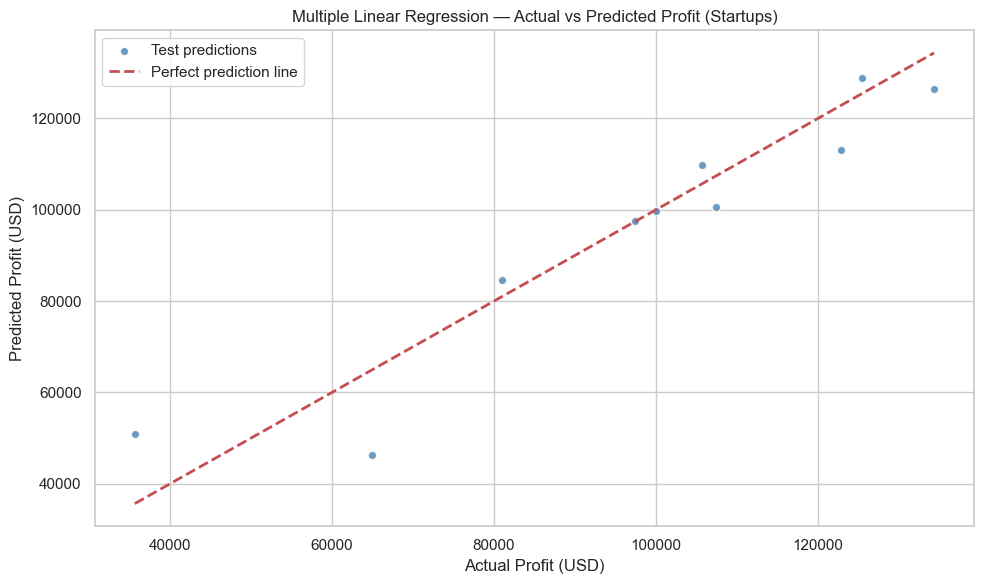

In [9]:
# Step 7) Visualization — Actual vs Predicted
plt.figure(figsize=(10, 6))  # Create a new figure with custom size
plt.scatter(y_test, y_pred_test, color='steelblue', alpha=0.8, edgecolors='white', label='Test predictions')  # Plot points

min_val = min(y_test.min(), y_pred_test.min())  # Find minimum value for diagonal line range
max_val = max(y_test.max(), y_pred_test.max())  # Find maximum value for diagonal line range
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction line')  # Ideal 45° line

plt.xlabel('Actual Profit (USD)')       # Label for x-axis
plt.ylabel('Predicted Profit (USD)')    # Label for y-axis
plt.title('Multiple Linear Regression — Actual vs Predicted Profit (Startups)')  # Chart title
plt.legend()             # Show legend
plt.tight_layout()       # Adjust spacing so labels are not cut off
plt.show()               # Display the plot


## Example 1 — Cell 8: Evaluation

Evaluate the model on the test set using MAE, RMSE, and R² (Coefficient of Determination).

**What this cell does:** Computes and displays regression evaluation metrics.


In [10]:
# Step 8) Evaluation
mae = mean_absolute_error(y_test, y_pred_test)              # Average absolute prediction error
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))     # Square-root of average squared error
r2 = r2_score(y_test, y_pred_test)                          # Proportion of variance explained by the model

results = pd.DataFrame({  # Build a table of evaluation metrics
    'Metric': ['MAE', 'RMSE', 'R²'],  # Metric names
    'Value': [mae, rmse, r2],         # Computed metric values
    'Description': [                   # Short explanation of each metric
        'Mean Absolute Error (USD)',
        'Root Mean Squared Error (USD)',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))  # Show metrics rounded to 4 decimal places
print(f'\nExample 1 Test R² = {r2:.4f}')  # Print R² for easy reference


,Metric,Value,Description
0,MAE,6961.4778,Mean Absolute Error (USD)
1,RMSE,9055.9573,Root Mean Squared Error (USD)
2,R²,0.8987,Coefficient of Determination (1 = perfect)



Example 1 Test R² = 0.8987


## Why is R² ≈ 0.8987?

The 50 Startups dataset is a **classic Multiple Linear Regression** example. Profit is designed to depend linearly on R&D, Administration, Marketing, and State.

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Multiple relevant features** | Profit is explained by spending in three departments plus location — not just one variable |
| 2 | **Linear relationship** | The true relationship between spend and profit is approximately linear |
| 3 | **Categorical State encoded** | One-Hot Encoding lets the model capture regional differences in profitability |
| 4 | **Low noise** | Data points cluster close to the regression hyperplane → **high R²** |
| 5 | **Interpretable coefficients** | Each coefficient shows how Profit changes when one feature increases (holding others fixed) |

> **Summary:** R² ≈ 0.8987 = **excellent fit** — the model explains about **90%** of Profit variation because the problem matches Multiple Linear Regression assumptions.


---
# Example 2: House Price — Multiple Linear Regression

Predict **Price** from three numeric property features.

| Column | Role | Description |
|--------|------|-------------|
| `Area_sqft` | Feature (X₁) | Living area in square feet |
| `Bedrooms` | Feature (X₂) | Number of bedrooms |
| `Age_years` | Feature (X₃) | Age of the house in years |
| `Price` | Target (y) | Sale price in USD |

**File:** `../Datasets/house_price.csv`


## Example 2 — Cell 1: Load and Explore Data

Load the house price CSV and inspect the data.

**What this cell does:** Reads `../Datasets/house_price.csv` and displays basic statistics.


In [11]:
# Load the house price dataset
dataset = pd.read_csv('../Datasets/house_price.csv')  # Read CSV into a DataFrame

FEATURE_COLS = ['Area_sqft', 'Bedrooms', 'Age_years']  # Independent variables
TARGET_COL = 'Price'  # Dependent variable to predict

print('First 5 rows:')          # Print a label for the table below
display(dataset.head())         # Show the first 5 rows to inspect the data

print('\nDataset info:')       # Print a label for column types and null counts
dataset.info()                  # Show column names, data types, and non-null counts

print('\nStatistical summary:')  # Print a label for numeric statistics
display(dataset.describe())       # Show count, mean, std, min, max, quartiles

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')  # Total rows and columns


First 5 rows:


,Area_sqft,Bedrooms,Age_years,Price
0,1437.0,4,20.2,236600.0
1,2416.0,2,22.4,326978.0
2,2044.0,5,8.0,356625.0
3,1818.0,5,2.8,331845.0
4,1065.0,3,5.7,226326.0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area_sqft  79 non-null     float64
 1   Bedrooms   80 non-null     int64  
 2   Age_years  80 non-null     float64
 3   Price      79 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.6 KB

Statistical summary:


,Area_sqft,Bedrooms,Age_years,Price
count,79.000000,80.000000,80.000000,79.000000
mean,1585.101266,3.600000,12.356250,272120.303797
std,519.326502,1.097754,7.296502,63793.768063
min,809.000000,2.000000,0.200000,160117.000000
25%,1113.000000,3.000000,6.075000,221012.500000
50%,1534.000000,4.000000,12.500000,269066.000000
75%,2041.500000,4.250000,18.400000,330132.000000
max,2478.000000,5.000000,24.600000,380872.000000



Shape: 80 rows x 4 columns


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

Check for missing values, remove duplicates, and impute if needed.

**What this cell does:** Cleans the house price dataset before modeling.


In [12]:
# Data cleaning for house price dataset

print('Missing values per column:')  # Print a label
print(dataset.isnull().sum())        # Count NaN values in each column

rows_before = len(dataset)                              # Store row count before cleaning
dataset = dataset.drop_duplicates().reset_index(drop=True)  # Remove duplicate rows
rows_after = len(dataset)                               # Store row count after deduplication
print(f'\nDuplicates removed: {rows_before - rows_after}')  # Show duplicate count

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')  # Fill NaN with column mean
if dataset.isnull().sum().sum() > 0:               # If missing values exist
    dataset[FEATURE_COLS + [TARGET_COL]] = imputer.fit_transform(dataset[FEATURE_COLS + [TARGET_COL]])  # Impute
    print('Missing values imputed with mean')      # Confirm imputation
else:
    print('No missing values — imputer not applied')  # Skip when complete

print(f'\nRows after cleaning: {rows_after}')    # Final row count


Missing values per column:
Area_sqft    1
Bedrooms     0
Age_years    0
Price        1
dtype: int64

Duplicates removed: 0
Missing values imputed with mean

Rows after cleaning: 80


## Example 2 — Cell 3: Categorical Data Encoding

All feature columns are numeric — encoding is skipped.

**What this cell does:** Detects categorical columns and applies encoding if needed.


In [13]:
# Categorical encoding

cat_cols = [col for col in FEATURE_COLS if dataset[col].dtype == 'object']  # Find text columns in features

if cat_cols:  # Encode only when categorical columns exist
    print(f'Categorical columns found: {cat_cols}')  # List columns that need encoding
    preprocessor = ColumnTransformer(
        transformers=[('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )
    X_array = preprocessor.fit_transform(dataset[FEATURE_COLS])
    feature_names = preprocessor.get_feature_names_out()
    X = pd.DataFrame(X_array, columns=feature_names)
    print('One-Hot Encoding applied')
else:
    X = dataset[FEATURE_COLS].copy()  # All features are already numeric
    print('No categorical columns — encoding skipped.')  # Nothing to encode
    print(f'Numeric feature columns: {list(X.columns)}')  # Show feature names

y = dataset[TARGET_COL].values  # Target vector: house prices


No categorical columns — encoding skipped.
Numeric feature columns: ['Area_sqft', 'Bedrooms', 'Age_years']


## Example 2 — Cell 4: Splitting the Data

Define X (Area, Bedrooms, Age) and y (Price), then split 80/20.

**What this cell does:** Creates feature/target arrays and applies train_test_split.


In [14]:
# Train-Test split

X_values = X.values  # Feature matrix as numpy array
y_values = y         # Target vector

X_train, X_test, y_train, y_test = train_test_split(
    X_values, y_values,  # Data to split
    test_size=0.2,       # 20% test, 80% train
    random_state=42      # Reproducible split
)

print(f'X_train shape: {X_train.shape}')  # Training features shape
print(f'X_test shape:  {X_test.shape}')   # Test features shape
print(f'y_train shape: {y_train.shape}')  # Training targets shape
print(f'y_test shape:  {y_test.shape}')   # Test targets shape


X_train shape: (64, 3)
X_test shape:  (16, 3)
y_train shape: (64,)
y_test shape:  (16,)


## Example 2 — Cell 5: Train the Model

Train Multiple Linear Regression: `Price = b₀ + b₁·Area + b₂·Bedrooms + b₃·Age`

**What this cell does:** Fits the model and prints the regression equation.


In [15]:
# Train model
regressor = LinearRegression()      # Create Multiple Linear Regression model
regressor.fit(X_train, y_train)     # Learn intercept and all coefficients

print(f'Intercept (b0): {regressor.intercept_:.2f}')  # Base price when all features are zero
print('\nCoefficients:')  # Print a label
for name, coef in zip(X.columns, regressor.coef_):  # Loop through each feature coefficient
    print(f'  {name}: {coef:.2f}')  # Show price change per 1-unit feature increase

equation_terms = ' + '.join([f'{c:.2f} x {n}' for n, c in zip(X.columns, regressor.coef_)])  # Equation terms
print(f'\nEquation: {TARGET_COL} = {regressor.intercept_:.2f} + {equation_terms}')  # Full equation


Intercept (b0): 66902.23

Coefficients:
  Area_sqft: 117.31
  Bedrooms: 12859.69
  Age_years: -2259.39

Equation: Price = 66902.23 + 117.31 x Area_sqft + 12859.69 x Bedrooms + -2259.39 x Age_years


## Example 2 — Cell 6: Predict

Predict house prices for training and test samples.

**What this cell does:** Generates predictions and shows sample comparisons.


In [16]:
# Predict
y_pred_train = regressor.predict(X_train)  # Predict price for training data
y_pred_test = regressor.predict(X_test)    # Predict price for test data

print('Sample predictions (Test set):')  # Print a label
for i in range(min(5, len(y_test))):     # Show first 5 test predictions
    print(f'  Actual Price=${y_test[i]:,.0f}, Predicted=${y_pred_test[i]:,.0f}')  # Compare actual vs predicted


Sample predictions (Test set):
  Actual Price=$275,993, Predicted=$282,078
  Actual Price=$236,600, Predicted=$241,272
  Actual Price=$228,054, Predicted=$229,613
  Actual Price=$232,660, Predicted=$232,650
  Actual Price=$238,764, Predicted=$252,011


## Example 2 — Cell 7: Visualization

Scatter plot of Actual vs Predicted house prices on the test set.

**What this cell does:** Plots true prices against model predictions.


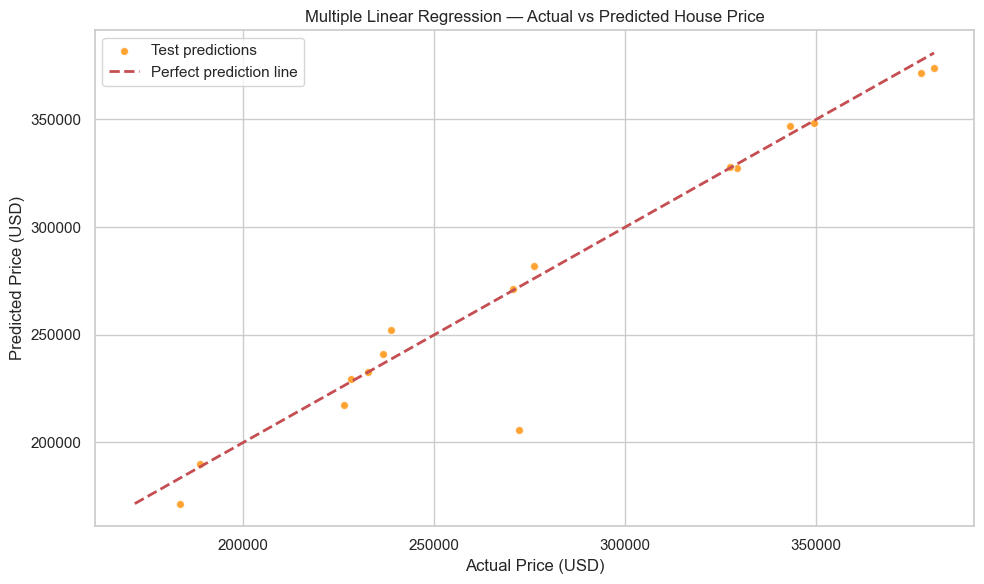

In [17]:
# Visualization — Actual vs Predicted
plt.figure(figsize=(10, 6))  # Create figure
plt.scatter(y_test, y_pred_test, color='darkorange', alpha=0.8, edgecolors='white', label='Test predictions')  # Scatter

min_val = min(y_test.min(), y_pred_test.min())  # Minimum for diagonal line
max_val = max(y_test.max(), y_pred_test.max())  # Maximum for diagonal line
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction line')  # Ideal line

plt.xlabel('Actual Price (USD)')        # X-axis label
plt.ylabel('Predicted Price (USD)')     # Y-axis label
plt.title('Multiple Linear Regression — Actual vs Predicted House Price')  # Chart title
plt.legend()             # Show legend
plt.tight_layout()       # Adjust layout
plt.show()               # Display plot


## Example 2 — Cell 8: Evaluation

Evaluate model performance with MAE, RMSE, and R².

**What this cell does:** Computes and displays evaluation metrics on the test set.


In [18]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred_test)              # Mean absolute error in USD
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))     # Root mean squared error
r2 = r2_score(y_test, y_pred_test)                          # Variance explained (closer to 1 is better)

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae, rmse, r2],
    'Description': [
        'Mean Absolute Error (USD)',
        'Root Mean Squared Error (USD)',
        'Coefficient of Determination (1 = perfect)'
    ]
})

display(results.round(4))
print(f'\nExample 2 Test R² = {r2:.4f}')  # Print R² for easy reference


,Metric,Value,Description
0,MAE,8440.6321,Mean Absolute Error (USD)
1,RMSE,17640.2309,Root Mean Squared Error (USD)
2,R²,0.9202,Coefficient of Determination (1 = perfect)



Example 2 Test R² = 0.9202


## Why is R² ≈ 0.9202?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Area drives price** | Larger homes (sqft) generally cost more — strong positive coefficient |
| 2 | **Bedrooms add value** | More bedrooms typically increase sale price |
| 3 | **Age reduces price** | Older homes often sell for less (negative Age coefficient expected) |
| 4 | **Multiple features together** | MLR combines all three signals — better than any single feature alone |
| 5 | **Synthetic linear data** | This dataset is generated with a near-linear price formula plus small noise |

> **Summary:** R² ≈ 0.9202 = **excellent fit** — the model explains about **92%** of price variation because area, bedrooms, and age jointly capture the linear relationship.
